In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import curve_fit
from scipy.stats import moyal
import pickle

Delta t

In [2]:
dtpath = '/raid1/genli/Data_D2O/M1_data/analysis_20355-20525_step1_M1_20260227-020611/MASTER_RESULTS/aggregated_delta_t_step1.pkl'
#auto-detect the model (M1 or M2) from the path
if 'M1' in dtpath:
    model = '1'
elif 'M2' in dtpath:
    model = '2'
#auto-detect the run range from the path
import re
run_range_match = re.search(r'analysis_(\d+-\d+)_step1', dtpath)

# show pkl structure
import pickle
with open(dtpath, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

#load centers, histograms and errors
centers = data['centers']
histograms = data['histograms']
errors = data['errors']

dict_keys(['centers', 'histograms', 'errors', 'fit_model', 'fit_params', 'fit_stats'])


In [3]:
#print fit_model and fit_params
print(data['fit_model'])
print(data['fit_params'])

A*exp(-(t-t0)/tau)+c
{'A': 46248.8670297027, 'tau': 2075.781750175963, 'c': 1.7919458695331395e-11, 't0': 2560.0, 'A_err': 95.91602083557392, 'tau_err': 7.198491363774861, 'c_err': 26.39719197841393}


In [4]:
print(centers)

[ 2480.  2640.  2800.  2960.  3120.  3280.  3440.  3600.  3760.  3920.
  4080.  4240.  4400.  4560.  4720.  4880.  5040.  5200.  5360.  5520.
  5680.  5840.  6000.  6160.  6320.  6480.  6640.  6800.  6960.  7120.
  7280.  7440.  7600.  7760.  7920.  8080.  8240.  8400.  8560.  8720.
  8880.  9040.  9200.  9360.  9520.  9680.  9840. 10000. 10160. 10320.
 10480. 10640. 10800. 10960. 11120. 11280. 11440. 11600. 11760. 11920.
 12080. 12240. 12400. 12560. 12720. 12880. 13040. 13200. 13360. 13520.
 13680. 13840. 14000. 14160. 14320. 14480. 14640. 14800. 14960. 15120.
 15280. 15440. 15600. 15760. 15920. 16080. 16240. 16400. 16560. 16720.
 16880. 17040. 17200. 17360. 17520. 17680. 17840. 18000. 18160. 18320.
 18480. 18640. 18800. 18960. 19120. 19280. 19440. 19600. 19760. 19920.
 20080. 20240. 20400. 20560. 20720. 20880. 21040. 21200. 21360. 21520.
 21680. 21840. 22000. 22160. 22320. 22480. 22640. 22800. 22960. 23120.
 23280. 23440. 23600. 23760. 23920.]


In [5]:
# two single-exponential fits with user-fixed first boundary and 5σ second boundary
from scipy.optimize import curve_fit

def _pick_series(series_like, name, preferred_key=None):
    if isinstance(series_like, dict):
        if preferred_key is not None and preferred_key in series_like:
            key = preferred_key
        elif 'all' in series_like:
            key = 'all'
        elif 'total' in series_like:
            key = 'total'
        else:
            key = next(iter(series_like))
        print(f"Using {name}['{key}']")
        return np.asarray(series_like[key], dtype=float), key
    return np.asarray(series_like, dtype=float), preferred_key

# load arrays
centers_arr, key = _pick_series(centers, 'centers')
hist_arr, key = _pick_series(histograms, 'histograms', preferred_key=key)
err_arr, _ = _pick_series(errors, 'errors', preferred_key=key)

# keep valid points
mask = np.isfinite(centers_arr) & np.isfinite(hist_arr) & np.isfinite(err_arr) & (err_arr > 0)
x = centers_arr[mask]
y = hist_arr[mask]
sigma = err_arr[mask]

if len(x) < 40:
    raise ValueError('Need at least ~40 bins to fit two regions reliably.')

# fit model for each region: A*exp(-(x-x0)/tau)+C
def single_exp_local(xlocal, A, tau, C, x0):
    return A * np.exp(-(xlocal - x0) / tau) + C

def fit_single_region(xr, yr, sr):
    x0 = float(xr[0])
    C0 = max(0.0, float(np.percentile(yr, 10)))
    A0 = max(float(np.max(yr) - C0), 1.0)
    tau0 = max(float((xr[-1] - xr[0]) / 2.0), 100.0)

    def model_wrap(xlocal, A, tau, C):
        return single_exp_local(xlocal, A, tau, C, x0)

    p0 = [A0, tau0, C0]
    lb = [0.0, 50.0, 0.0]
    ub = [np.inf, 2.0e5, np.inf]

    popt, pcov = curve_fit(
        model_wrap, xr, yr, p0=p0, sigma=sr, absolute_sigma=True,
        bounds=(lb, ub), method='trf', max_nfev=100000
    )

    residual = yr - model_wrap(xr, *popt)
    chi2 = float(np.sum((residual / sr) ** 2))
    dof = max(len(xr) - len(popt), 1)
    red_chi2 = chi2 / dof
    return x0, popt, pcov, red_chi2

# 1) fixed boundary between first-fit and transition
transition_start = 15000.0
i_split = int(np.searchsorted(x, transition_start, side='left'))

min_fit_pts = 12
if i_split < min_fit_pts:
    raise ValueError(f'Not enough bins below {transition_start} ns for first fit.')

# first region fit (x < 15000 ns)
x1, y1, s1 = x[:i_split], y[:i_split], sigma[:i_split]
x01, popt1, pcov1, redchi1 = fit_single_region(x1, y1, s1)
A1_fit, tau1_fit, C1_fit = popt1
perr1 = np.sqrt(np.clip(np.diag(pcov1), 0.0, np.inf))
tau1_err = float(perr1[1])

# 2) second boundary = first sustained 5σ deviation from section-1 fit line
model1_all = A1_fit * np.exp(-(x - x01) / tau1_fit) + C1_fit
pull1_all = (y - model1_all) / sigma

idx_after = np.where(x >= transition_start)[0]
if len(idx_after) == 0:
    raise ValueError('No bins at or above 15000 ns found.')

consecutive_needed = 3
sigma_threshold = 5.0
j_split = None
run = 0
for idx in idx_after:
    if np.abs(pull1_all[idx]) >= sigma_threshold:
        run += 1
    else:
        run = 0
    if run >= consecutive_needed:
        j_split = idx - consecutive_needed + 1
        break

# fallback: if no 5σ crossing, start section-2 at end of available range block
if j_split is None:
    j_split = min(i_split + max(6, int(0.08 * len(x))), len(x) - min_fit_pts)

if j_split <= i_split:
    j_split = min(i_split + 1, len(x) - min_fit_pts)

transition_end = float(x[j_split - 1])

# second region fit (x > transition_end)
x2, y2, s2 = x[j_split:], y[j_split:], sigma[j_split:]
if len(x2) < min_fit_pts:
    raise ValueError('Not enough bins in second region after transition for second fit.')

x02, popt2, pcov2, redchi2 = fit_single_region(x2, y2, s2)
A2_fit, tau2_fit, C2_fit = popt2
perr2 = np.sqrt(np.clip(np.diag(pcov2), 0.0, np.inf))
tau2_err = float(perr2[1])

print(f'First fit region:      x < {transition_start:.1f} ns')
print(f'Transition region:     {transition_start:.1f} to {transition_end:.1f} ns')
print(f'Second fit region:     x > {transition_end:.1f} ns')
print('---')
print(f'tau1 = {tau1_fit:.2f} ± {tau1_err:.2f} ns   (reduced chi2 = {redchi1:.2f})')
print(f'tau2 = {tau2_fit:.2f} ± {tau2_err:.2f} ns   (reduced chi2 = {redchi2:.2f})')

Using histograms['Master Runs 20355-20525']
Using errors['Master Runs 20355-20525']
First fit region:      x < 15000.0 ns
Transition region:     15000.0 to 16560.0 ns
Second fit region:     x > 16560.0 ns
---
tau1 = 2080.83 ± 3.61 ns   (reduced chi2 = 3.03)
tau2 = 1776.34 ± 216.68 ns   (reduced chi2 = 0.94)


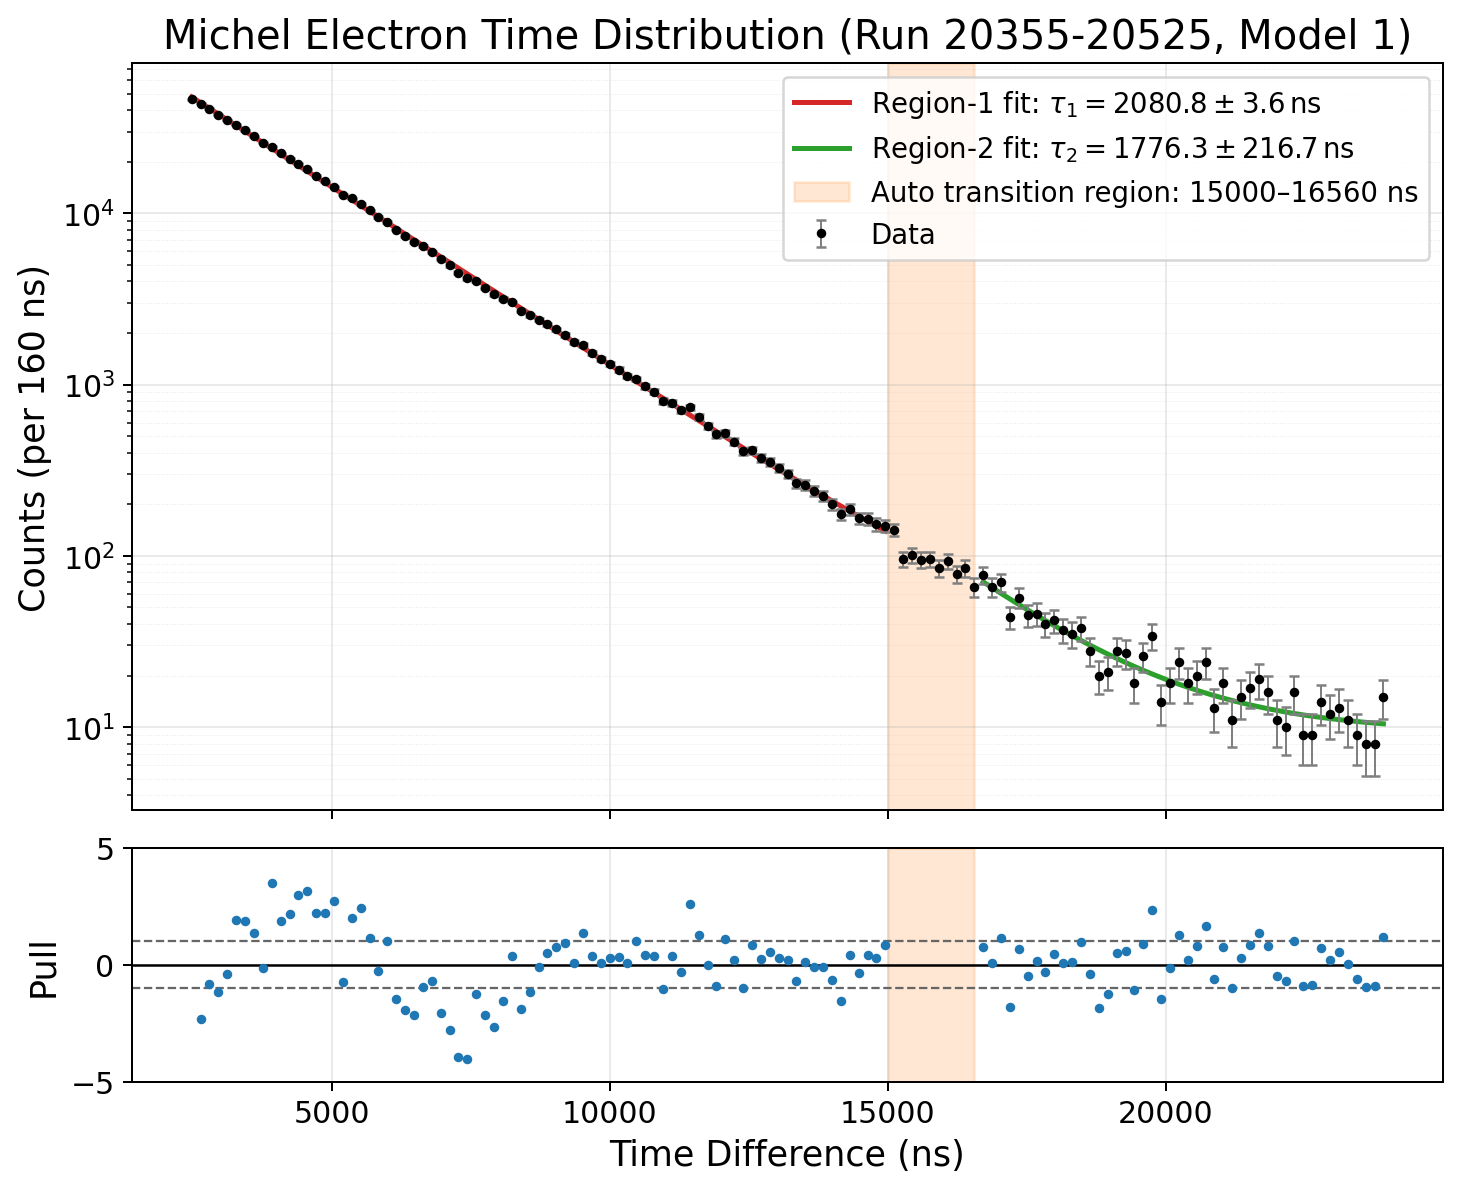

In [6]:
# thesis-ready plot: two single-exponential fits + automatic transition band
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11
})

fig, (ax, ax_pull) = plt.subplots(
    2, 1, figsize=(8.0, 6.5), dpi=180,
    gridspec_kw={'height_ratios': [3.2, 1.0], 'hspace': 0.03},
    sharex=True,
    constrained_layout=True
)

# data
data_handle = ax.errorbar(
    x, y, yerr=sigma, fmt='o', ms=2.8, lw=0.8, capsize=2.0,
    color='black', ecolor='gray', elinewidth=0.8, label='Data', zorder=3
)

# region 1 fit curve
xfit1 = np.linspace(x1[0], x1[-1], 500)
yfit1 = A1_fit * np.exp(-(xfit1 - x01) / tau1_fit) + C1_fit
fit1_handle, = ax.plot(
    xfit1, yfit1, color='tab:red', lw=2.0,
    label=rf'Region-1 fit: $\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}\,\mathrm{{ns}}$',
    zorder=2
)

# region 2 fit curve
xfit2 = np.linspace(x2[0], x2[-1], 500)
yfit2 = A2_fit * np.exp(-(xfit2 - x02) / tau2_fit) + C2_fit
fit2_handle, = ax.plot(
    xfit2, yfit2, color='tab:green', lw=2.0,
    label=rf'Region-2 fit: $\tau_2={tau2_fit:.1f}\pm{tau2_err:.1f}\,\mathrm{{ns}}$',
    zorder=2
)

# transition band
transition_label = f'Auto transition region: {transition_start:.0f}–{transition_end:.0f} ns'
ax.axvspan(transition_start, transition_end, color='tab:orange', alpha=0.18, label=transition_label)
binwidth = float(x[1] - x[0]) if len(x) > 1 else 100.0
ax.set_ylabel(f'Counts (per {binwidth:.0f} ns)')
ax.set_yscale('log')
ax.set_title(f'Michel Electron Time Distribution (Run {run_range_match.group(1)}, Model {model})')
ax.legend(loc='upper right', frameon=True)
ax.grid(True, which='major', linestyle='-', linewidth=0.6, alpha=0.35)
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.25)

# pull panel relative to piecewise model (transition bins omitted)
piecewise_model = np.full_like(y, np.nan, dtype=float)
left_mask = x < transition_start
right_mask = x > transition_end
piecewise_model[left_mask] = A1_fit * np.exp(-(x[left_mask] - x01) / tau1_fit) + C1_fit
piecewise_model[right_mask] = A2_fit * np.exp(-(x[right_mask] - x02) / tau2_fit) + C2_fit
pull = np.full_like(y, np.nan, dtype=float)
valid_pull = np.isfinite(piecewise_model)
pull[valid_pull] = (y[valid_pull] - piecewise_model[valid_pull]) / sigma[valid_pull]

ax_pull.axhline(0, color='black', lw=1.0)
ax_pull.axhline(1, color='0.4', lw=0.9, ls='--')
ax_pull.axhline(-1, color='0.4', lw=0.9, ls='--')
ax_pull.axvspan(transition_start, transition_end, color='tab:orange', alpha=0.18)
ax_pull.plot(x[valid_pull], pull[valid_pull], 'o', ms=2.8, color='tab:blue')
ax_pull.set_ylabel('Pull')
ax_pull.set_xlabel('Time Difference (ns)')
ax_pull.set_ylim(-5, 5)
ax_pull.grid(True, which='major', linestyle='-', linewidth=0.6, alpha=0.35)

# fig.savefig('michel_electron_two_region_fit_thesis.pdf', bbox_inches='tight')
fig.savefig(f'michel_electron_two_region_fit_run_{run_range_match.group(1)}_M{model}.png', dpi=300, bbox_inches='tight')
plt.show()